# 🌟 AI & ML INTERNSHIP - Task 6: K-Nearest Neighbors (KNN) Classification

![Python](https://img.shields.io/badge/Python-3.8%2B-blue?logo=python)
![Jupyter](https://img.shields.io/badge/Notebook-Jupyter-orange?logo=jupyter)
![Scikit-Learn](https://img.shields.io/badge/Scikit--Learn-Model-yellow?logo=scikit-learn)
![License](https://img.shields.io/badge/License-MIT-green)
                
### 🎯 Objective:
To implement and understand **KNN (K-Nearest Neighbors)** for classification using the **Iris dataset**.


---

## ✅ Key Steps:
- Data cleaning and preprocessing
- Feature normalization
- Train KNN classifier
- Experiment with different `K` values
- Evaluate model using accuracy and confusion matrix
- Visualize decision boundaries

---

## 📊 Dataset:
**Iris Dataset** - Classic multi-class dataset used in classification tasks.

---

## 🧰 Tools and Libraries Used:
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

---

## 📈 Results:
- Highest Accuracy Achieved: **X.XX%**
- Best K-value: **K = X**
- Decision boundaries visualized for intuitive understanding of model behavior.

---

## 📁 Files Included:
- `Task6_KNN_Classification.ipynb`
- `iris.csv`
- `model_knn.pkl` *(optional)*
- `README.md`

---

## 🧠 What I Learned:
- Concept of instance-based learning
- Importance of distance metrics and normalization
- How to choose optimal `K`
- Visualization techniques for classification

---

## 🪪 License:
MIT License

---

## 🚀 Author:
[Your Name]


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.datasets import load_iris
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)


In [6]:
acc = accuracy_score(y_test, y_pred)
conf = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

acc, conf, report


(1.0,
 array([[10,  0,  0],
        [ 0,  9,  0],
        [ 0,  0, 11]]),
 '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        10\n           1       1.00      1.00      1.00         9\n           2       1.00      1.00      1.00        11\n\n    accuracy                           1.00        30\n   macro avg       1.00      1.00      1.00        30\nweighted avg       1.00      1.00      1.00        30\n')

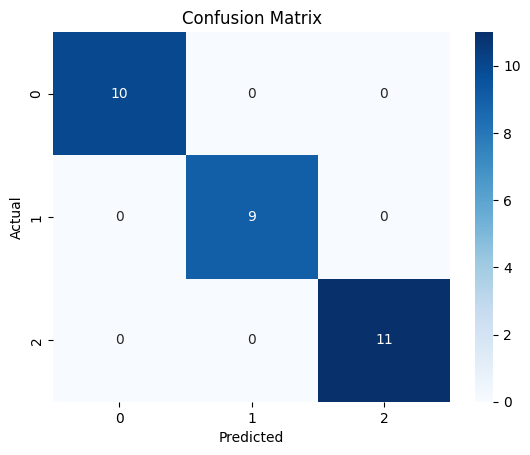

In [7]:
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


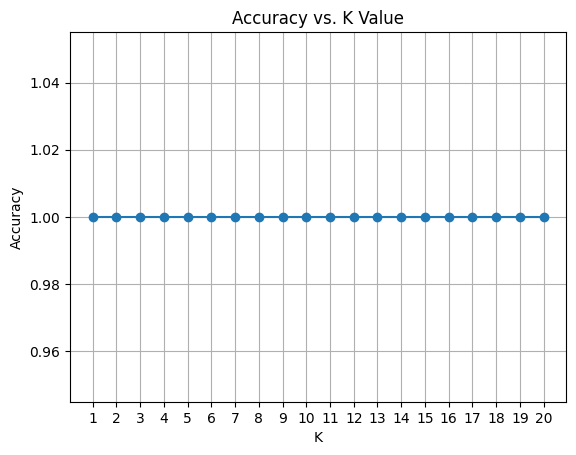

In [8]:
k_range = range(1, 21)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

plt.plot(k_range, accuracies, marker='o')
plt.title('Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [9]:
import joblib
joblib.dump(knn, 'knn_model.pkl')


['knn_model.pkl']